# BoW 기반 텍스트 분석 연습
1. 적절한 데이터셋을 찾거나 생성하고, 적절한 전처리를 진행한다. (01_preprocessing.ipynb)
    - 대화형 데이터셋은 이번 내용에서 사용하기 좀 힘들 것임 다른 데이터셋 찾아보기
2. TF-IDF Vectorizer를 이용하여 백터화한다.
3. Cosine Similarity를 계산하여 입력된 문자열의 긍/부정을 판단한다. 

**4가지 경우** 시도해보기

---

## 다른 기기에서 nlp_env 환경 커널 이용 확인

In [3]:
from konlpy.tag import Okt
okt = Okt()
okt.nouns("이번 프로젝트에서 발표를 하는데 내가 실수했어.")

: 

- 집에서 새로 가상환경 설정하고 실습 시간에 했던 똑같은 조건으로 하려고 했으나 지속된 에러(커널이 죽고 과련 모듈 불포함 등)로 kiwipiepy를 import 했습니다.

---

In [1]:
from kiwipiepy import Kiwi

kiwi = Kiwi()
text = "이번 프로젝트에서 발표를 하는데 내가 실수했어."

tokens = kiwi.tokenize(text)
tokens

[Token(form='이번', tag='NNG', start=0, len=2),
 Token(form='프로젝트', tag='NNG', start=3, len=4),
 Token(form='에서', tag='JKB', start=7, len=2),
 Token(form='발표', tag='NNG', start=10, len=2),
 Token(form='를', tag='JKO', start=12, len=1),
 Token(form='하', tag='VV', start=14, len=1),
 Token(form='는데', tag='EC', start=15, len=2),
 Token(form='나', tag='NP', start=18, len=1),
 Token(form='가', tag='JKS', start=19, len=1),
 Token(form='실수', tag='NNG', start=21, len=2),
 Token(form='하', tag='XSV', start=23, len=1),
 Token(form='었', tag='EP', start=23, len=1),
 Token(form='어', tag='EF', start=24, len=1),
 Token(form='.', tag='SF', start=25, len=1)]

In [2]:
nouns = [t.form for t in kiwi.tokenize(text) if t.tag.startswith("N")]
nouns

['이번', '프로젝트', '발표', '나', '실수']

---

In [ ]:
#!pip install pandas
#!pip install numpy

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -------- ------------------------------- 2.4/11.3 MB 11.2 MB/s eta 0:00:01
   --------------- ------------------------ 4.5/11.3 MB 10.8 MB/s eta 0:00:01
   ------------------------ --------------- 7.1/11.3 MB 11.2 MB/s eta 0:00:01
   --------------------------------- ------ 9.4/11.3 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 11.1 MB/s  0:00:01
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   ------------------

In [5]:
import pandas as pd
import numpy as np

In [6]:
emotion_df=pd.read_csv('C:\\SKN_24\\과제\\nlp_practice\\data\\감성대화말뭉치(최종데이터)_Validation.csv')
emotion_df

,Unnamed: 0,연령,성별,상황키워드,신체질환,감정_대분류,감정_소분류,사람문장1,시스템문장1,사람문장2,시스템문장2,사람문장3,시스템문장3
0,1,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,실수하시다니 정말 미안한 마음이 크겠어요.,내 능력이 부족한 거 같은데 그만 다녀야 될거같아.,능력을 올리려면 어떤 방법이 있을까요?,퇴근 후 여가에 회사 일을 더 열심히 해서 피해가 가지 않도록 해야겠어.,꼭 좋은 결과 있길 바라요.
1,2,청년,남성,"진로,취업,직장",해당없음,불안,두려운,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,큰 프로젝트를 혼자 하셔서 고민이 많겠네요.,나에게 너무 크게 느껴지는 중요한 프로젝트라 버거운 느낌이 들어.,프로젝트를 잘하시기 위해서 어떤 걸 할 수 있나요?,동료 직원에게 도움을 요청해서 같이 해결해야겠어.,동료 직원에게 도움을 요청하기로 하셨군요.
2,3,청년,남성,"진로,취업,직장",해당없음,불안,두려운,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.,무섭게 생겼는데도 업무를 보려면 친해져야 할 것 같단말이야.,상사분과 친해질 수 있는 방법은 무엇이 있을까요?,먼저 다가가서 말을 걸어볼게.,직장 상사와 친해지시면 좋겠네요.
3,4,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.,첫 직장이어서 잘 적응을 할 수 있을지 모르겠어.,잘 적응 하시려면 무엇을 할 수 있을까요?,직장 동료와 상사들이랑 친하게 지내야겠어.,직장에 잘 적응하시길 바라요.
4,5,청년,남성,"진로,취업,직장",해당없음,불안,두려운,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,직장 사람들 관계에 대해서 고민이시군요.,내가 낯가림이 심해서 친해질 수 있을지 모르겠어.,직장 사람들과 친해지려면 무슨 방법이 있을까요?,서로 같은 취미를 공유하고 얘기를 나누다 보면 친해질 수 있을 거 같아.,직장 사람들과 좋은 관계를 가지시길 응원해요.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6636,6637,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,나랑 비슷한 시기에 결혼하는 친구는 시댁에서 집을 해줘서 너무 부러워. 우리는 대출...,같은 시기에 결혼하는 친구들끼리 상황이 다르다 보니 마음이 좋지 않으시겠어요.,우리만 뒤처지는 것 같고. 그래도 열심히 살다 보면 우리도 집을 살 수 있겠지?,우리 부부만 뒤처지는 것 같아 속상하지만 열심히 살다 보면 집을 살 수 있다고 믿으...,NaN,NaN
6637,6638,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,친구 한 명이 결혼해서 아이를 가졌는데 너무 행복해 보이더라. 기분이 좋지만은 않아.,기분이 좋지 않으신 이유를 알고 계시나요?,나도 결혼했지만 아이도 생기지 않고 그 정도로 행복하지 않거든. 친구보다 못사는 것...,친구분과 비교하게 되어 기분이 좋지 않으셨군요. 어떻게 하면 기분이 풀릴 수 있을까요?,NaN,NaN
6638,6639,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,남들은 결혼 전에 일억을 모았다는데 난 뭐를 한 것인지 모르겠어. 자괴감만 드네.,돈을 모으는 것으로 자괴감이 드시는군요.,요새 집값이 너무 올라서 한숨만 나와.,집값이 올라 한숨만 나오시는군요.,NaN,NaN
6639,6640,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,나보다 결혼을 먼저 한 친구가 부러워. 그 친구 남편은 직장도 내 남편보다 좋고 키...,먼저 결혼한 친구가 부럽군요.,맞아. 그 친구와 비교하게 되니 자존감이 낮아지는 기분이야.,비교로 자존감이 낮아지는군요.,NaN,NaN


In [ ]:
emotion_df=emotion_df.drop(columns=['Unnamed: 0','연령','성별','상황키워드','신체질환','감정_대분류','감정_소분류'])
# drop -> 해당 컬럼을 drop하고 나머지 컬럼만 가져옴
emotion_df

,사람문장1,시스템문장1,사람문장2,시스템문장2,사람문장3,시스템문장3
0,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,실수하시다니 정말 미안한 마음이 크겠어요.,내 능력이 부족한 거 같은데 그만 다녀야 될거같아.,능력을 올리려면 어떤 방법이 있을까요?,퇴근 후 여가에 회사 일을 더 열심히 해서 피해가 가지 않도록 해야겠어.,꼭 좋은 결과 있길 바라요.
1,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,큰 프로젝트를 혼자 하셔서 고민이 많겠네요.,나에게 너무 크게 느껴지는 중요한 프로젝트라 버거운 느낌이 들어.,프로젝트를 잘하시기 위해서 어떤 걸 할 수 있나요?,동료 직원에게 도움을 요청해서 같이 해결해야겠어.,동료 직원에게 도움을 요청하기로 하셨군요.
2,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.,무섭게 생겼는데도 업무를 보려면 친해져야 할 것 같단말이야.,상사분과 친해질 수 있는 방법은 무엇이 있을까요?,먼저 다가가서 말을 걸어볼게.,직장 상사와 친해지시면 좋겠네요.
3,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.,첫 직장이어서 잘 적응을 할 수 있을지 모르겠어.,잘 적응 하시려면 무엇을 할 수 있을까요?,직장 동료와 상사들이랑 친하게 지내야겠어.,직장에 잘 적응하시길 바라요.
4,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,직장 사람들 관계에 대해서 고민이시군요.,내가 낯가림이 심해서 친해질 수 있을지 모르겠어.,직장 사람들과 친해지려면 무슨 방법이 있을까요?,서로 같은 취미를 공유하고 얘기를 나누다 보면 친해질 수 있을 거 같아.,직장 사람들과 좋은 관계를 가지시길 응원해요.
...,...,...,...,...,...,...
6636,나랑 비슷한 시기에 결혼하는 친구는 시댁에서 집을 해줘서 너무 부러워. 우리는 대출...,같은 시기에 결혼하는 친구들끼리 상황이 다르다 보니 마음이 좋지 않으시겠어요.,우리만 뒤처지는 것 같고. 그래도 열심히 살다 보면 우리도 집을 살 수 있겠지?,우리 부부만 뒤처지는 것 같아 속상하지만 열심히 살다 보면 집을 살 수 있다고 믿으...,NaN,NaN
6637,친구 한 명이 결혼해서 아이를 가졌는데 너무 행복해 보이더라. 기분이 좋지만은 않아.,기분이 좋지 않으신 이유를 알고 계시나요?,나도 결혼했지만 아이도 생기지 않고 그 정도로 행복하지 않거든. 친구보다 못사는 것...,친구분과 비교하게 되어 기분이 좋지 않으셨군요. 어떻게 하면 기분이 풀릴 수 있을까요?,NaN,NaN
6638,남들은 결혼 전에 일억을 모았다는데 난 뭐를 한 것인지 모르겠어. 자괴감만 드네.,돈을 모으는 것으로 자괴감이 드시는군요.,요새 집값이 너무 올라서 한숨만 나와.,집값이 올라 한숨만 나오시는군요.,NaN,NaN
6639,나보다 결혼을 먼저 한 친구가 부러워. 그 친구 남편은 직장도 내 남편보다 좋고 키...,먼저 결혼한 친구가 부럽군요.,맞아. 그 친구와 비교하게 되니 자존감이 낮아지는 기분이야.,비교로 자존감이 낮아지는군요.,NaN,NaN


In [ ]:
#!pip install wordcloud

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 11.2 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.1 MB 11.2 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.5 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 10.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------- -------------------------- 2.4/7.0 MB 12.2 MB/s eta 0:00:01
   ---------------------------- ----------- 5.0/7.0 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 11.7 MB/s  0:00:00
Usi

In [ ]:
#!pip install gdown

  Using cached gdown-5.2.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
Using cached gdown-5.2.1-py3-none-any.whl (18 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
Using cached soupsieve-2.8.3-py3-none-any.whl (37 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
Using cached PySocks-1.7.1-py3-none-any.whl (16 kB)

   ----------------------------------------  0/10

In [9]:
corpus = emotion_df['사람문장1'][0]
corpus

'이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너무 미안해.'

# wordcloud 과정
1. 텍스트 전처리
2. 단어 빈도 계
3. wordcloud 설정
4. 시각화

In [10]:
!pip install konlpy

  Using cached jpype1-1.6.0-cp310-cp310-win_amd64.whl.metadata (5.1 kB)
Using cached jpype1-1.6.0-cp310-cp310-win_amd64.whl (356 kB)


In [ ]:
#pip install scikit_learn

In [12]:
from collections import Counter

word_count = Counter(nouns)
word_count

Counter({'이번': 1, '프로젝트': 1, '발표': 1, '나': 1, '실수': 1})

In [13]:
ko_stopwords = ['에서', '를','가','에','랑','은','만','보다','들','이','에게','로','과', '더']
word_count = {word: count for word, count in word_count.items() if word not in ko_stopwords}

In [14]:
# wordcloud 설정
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=800,
    font_path='C:\\Windows\\Fonts\\batang.ttc',
    background_color='white'
).generate_from_frequencies(word_count)

wordcloud

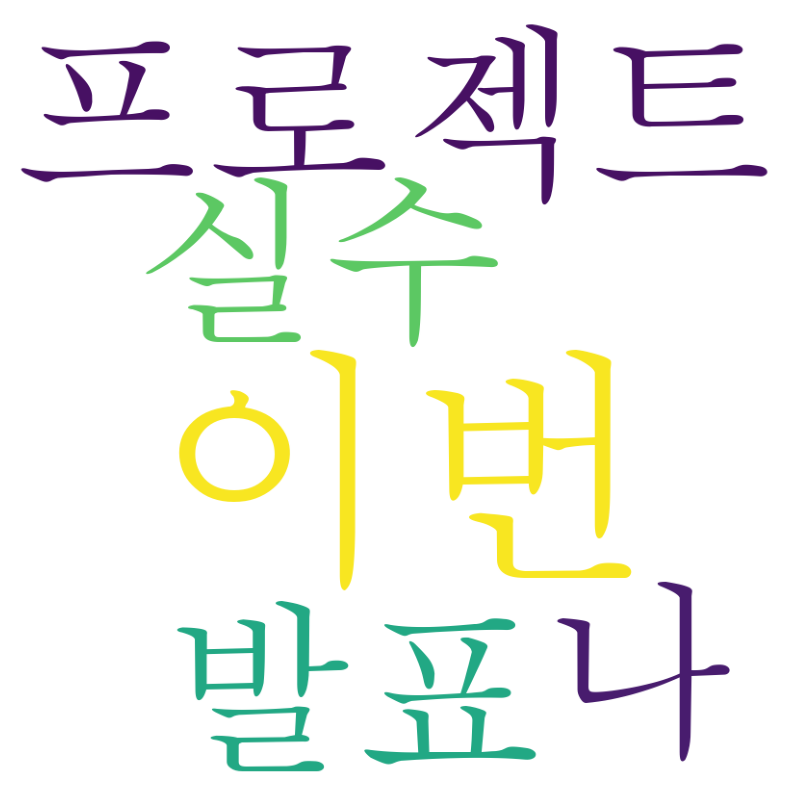

In [15]:
# 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

---

## 전체 데이터 사용하기
- corpus = emotion_all_df['사람문장1']
- 컬럼 '사람문장1'에 있는 텍스트 데이터 다 사용하기

In [2]:
import pandas as pd
import numpy as np

In [3]:
emotion_all_df=pd.read_csv('C:\\SKN_24\\과제\\nlp_practice\\data\\감성대화말뭉치(최종데이터)_Validation.csv')
emotion_all_df

,Unnamed: 0,연령,성별,상황키워드,신체질환,감정_대분류,감정_소분류,사람문장1,시스템문장1,사람문장2,시스템문장2,사람문장3,시스템문장3
0,1,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,실수하시다니 정말 미안한 마음이 크겠어요.,내 능력이 부족한 거 같은데 그만 다녀야 될거같아.,능력을 올리려면 어떤 방법이 있을까요?,퇴근 후 여가에 회사 일을 더 열심히 해서 피해가 가지 않도록 해야겠어.,꼭 좋은 결과 있길 바라요.
1,2,청년,남성,"진로,취업,직장",해당없음,불안,두려운,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,큰 프로젝트를 혼자 하셔서 고민이 많겠네요.,나에게 너무 크게 느껴지는 중요한 프로젝트라 버거운 느낌이 들어.,프로젝트를 잘하시기 위해서 어떤 걸 할 수 있나요?,동료 직원에게 도움을 요청해서 같이 해결해야겠어.,동료 직원에게 도움을 요청하기로 하셨군요.
2,3,청년,남성,"진로,취업,직장",해당없음,불안,두려운,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.,무섭게 생겼는데도 업무를 보려면 친해져야 할 것 같단말이야.,상사분과 친해질 수 있는 방법은 무엇이 있을까요?,먼저 다가가서 말을 걸어볼게.,직장 상사와 친해지시면 좋겠네요.
3,4,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.,첫 직장이어서 잘 적응을 할 수 있을지 모르겠어.,잘 적응 하시려면 무엇을 할 수 있을까요?,직장 동료와 상사들이랑 친하게 지내야겠어.,직장에 잘 적응하시길 바라요.
4,5,청년,남성,"진로,취업,직장",해당없음,불안,두려운,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,직장 사람들 관계에 대해서 고민이시군요.,내가 낯가림이 심해서 친해질 수 있을지 모르겠어.,직장 사람들과 친해지려면 무슨 방법이 있을까요?,서로 같은 취미를 공유하고 얘기를 나누다 보면 친해질 수 있을 거 같아.,직장 사람들과 좋은 관계를 가지시길 응원해요.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6636,6637,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,나랑 비슷한 시기에 결혼하는 친구는 시댁에서 집을 해줘서 너무 부러워. 우리는 대출...,같은 시기에 결혼하는 친구들끼리 상황이 다르다 보니 마음이 좋지 않으시겠어요.,우리만 뒤처지는 것 같고. 그래도 열심히 살다 보면 우리도 집을 살 수 있겠지?,우리 부부만 뒤처지는 것 같아 속상하지만 열심히 살다 보면 집을 살 수 있다고 믿으...,NaN,NaN
6637,6638,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,친구 한 명이 결혼해서 아이를 가졌는데 너무 행복해 보이더라. 기분이 좋지만은 않아.,기분이 좋지 않으신 이유를 알고 계시나요?,나도 결혼했지만 아이도 생기지 않고 그 정도로 행복하지 않거든. 친구보다 못사는 것...,친구분과 비교하게 되어 기분이 좋지 않으셨군요. 어떻게 하면 기분이 풀릴 수 있을까요?,NaN,NaN
6638,6639,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,남들은 결혼 전에 일억을 모았다는데 난 뭐를 한 것인지 모르겠어. 자괴감만 드네.,돈을 모으는 것으로 자괴감이 드시는군요.,요새 집값이 너무 올라서 한숨만 나와.,집값이 올라 한숨만 나오시는군요.,NaN,NaN
6639,6640,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,나보다 결혼을 먼저 한 친구가 부러워. 그 친구 남편은 직장도 내 남편보다 좋고 키...,먼저 결혼한 친구가 부럽군요.,맞아. 그 친구와 비교하게 되니 자존감이 낮아지는 기분이야.,비교로 자존감이 낮아지는군요.,NaN,NaN


In [4]:
emotion_all_df=emotion_all_df.drop(columns=['Unnamed: 0','연령','성별','상황키워드','신체질환','감정_대분류','감정_소분류'])
# drop -> 해당 컬럼을 drop하고 나머지 컬럼만 가져옴
emotion_all_df

,사람문장1,시스템문장1,사람문장2,시스템문장2,사람문장3,시스템문장3
0,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,실수하시다니 정말 미안한 마음이 크겠어요.,내 능력이 부족한 거 같은데 그만 다녀야 될거같아.,능력을 올리려면 어떤 방법이 있을까요?,퇴근 후 여가에 회사 일을 더 열심히 해서 피해가 가지 않도록 해야겠어.,꼭 좋은 결과 있길 바라요.
1,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,큰 프로젝트를 혼자 하셔서 고민이 많겠네요.,나에게 너무 크게 느껴지는 중요한 프로젝트라 버거운 느낌이 들어.,프로젝트를 잘하시기 위해서 어떤 걸 할 수 있나요?,동료 직원에게 도움을 요청해서 같이 해결해야겠어.,동료 직원에게 도움을 요청하기로 하셨군요.
2,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.,무섭게 생겼는데도 업무를 보려면 친해져야 할 것 같단말이야.,상사분과 친해질 수 있는 방법은 무엇이 있을까요?,먼저 다가가서 말을 걸어볼게.,직장 상사와 친해지시면 좋겠네요.
3,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.,첫 직장이어서 잘 적응을 할 수 있을지 모르겠어.,잘 적응 하시려면 무엇을 할 수 있을까요?,직장 동료와 상사들이랑 친하게 지내야겠어.,직장에 잘 적응하시길 바라요.
4,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,직장 사람들 관계에 대해서 고민이시군요.,내가 낯가림이 심해서 친해질 수 있을지 모르겠어.,직장 사람들과 친해지려면 무슨 방법이 있을까요?,서로 같은 취미를 공유하고 얘기를 나누다 보면 친해질 수 있을 거 같아.,직장 사람들과 좋은 관계를 가지시길 응원해요.
...,...,...,...,...,...,...
6636,나랑 비슷한 시기에 결혼하는 친구는 시댁에서 집을 해줘서 너무 부러워. 우리는 대출...,같은 시기에 결혼하는 친구들끼리 상황이 다르다 보니 마음이 좋지 않으시겠어요.,우리만 뒤처지는 것 같고. 그래도 열심히 살다 보면 우리도 집을 살 수 있겠지?,우리 부부만 뒤처지는 것 같아 속상하지만 열심히 살다 보면 집을 살 수 있다고 믿으...,NaN,NaN
6637,친구 한 명이 결혼해서 아이를 가졌는데 너무 행복해 보이더라. 기분이 좋지만은 않아.,기분이 좋지 않으신 이유를 알고 계시나요?,나도 결혼했지만 아이도 생기지 않고 그 정도로 행복하지 않거든. 친구보다 못사는 것...,친구분과 비교하게 되어 기분이 좋지 않으셨군요. 어떻게 하면 기분이 풀릴 수 있을까요?,NaN,NaN
6638,남들은 결혼 전에 일억을 모았다는데 난 뭐를 한 것인지 모르겠어. 자괴감만 드네.,돈을 모으는 것으로 자괴감이 드시는군요.,요새 집값이 너무 올라서 한숨만 나와.,집값이 올라 한숨만 나오시는군요.,NaN,NaN
6639,나보다 결혼을 먼저 한 친구가 부러워. 그 친구 남편은 직장도 내 남편보다 좋고 키...,먼저 결혼한 친구가 부럽군요.,맞아. 그 친구와 비교하게 되니 자존감이 낮아지는 기분이야.,비교로 자존감이 낮아지는군요.,NaN,NaN


In [7]:
corpus = emotion_all_df['사람문장1']

In [ ]:
#from konlpy.tag import Okt

In [10]:
#okt = Okt()
#
#nouns = []
#
#for corpus_temp in corpus:
#    nouns.extend(okt.nouns(corpus_temp))

RuntimeError: Can't find org.jpype.jar support library

In [ ]:
from kiwipiepy import Kiwi
from collections import Counter

#명사 추출
kiwi = Kiwi()

In [13]:
# 결측값 제거 + 문자열 변환
texts = corpus.fillna("").astype(str)

all_nouns = []

In [14]:
for sentence in texts:
    tokens = kiwi.tokenize(sentence)
    nouns = [t.form for t in tokens if t.tag.startswith("N") and len(t.form) > 1]
    all_nouns.extend(nouns)

len(all_nouns)

25110

In [15]:
# 단어 빈도 계산
word_freq = Counter(all_nouns)
word_freq.most_common(20)

[('친구', 1243),
 ('사람', 436),
 ('회사', 348),
 ('건강', 316),
 ('아내', 309),
 ('생각', 287),
 ('때문', 279),
 ('걱정', 268),
 ('남편', 253),
 ('학교', 250),
 ('우리', 239),
 ('이번', 238),
 ('요즘', 235),
 ('마음', 230),
 ('아들', 230),
 ('기분', 221),
 ('당황', 215),
 ('불안', 188),
 ('자식', 188),
 ('엄마', 186)]

In [18]:
from wordcloud import WordCloud

font_path = "C:/Windows/Fonts/malgun.ttf"
wc = WordCloud(
    font_path=font_path,
    background_color="white",
    width=800,
    height=600
).generate_from_frequencies(word_freq)

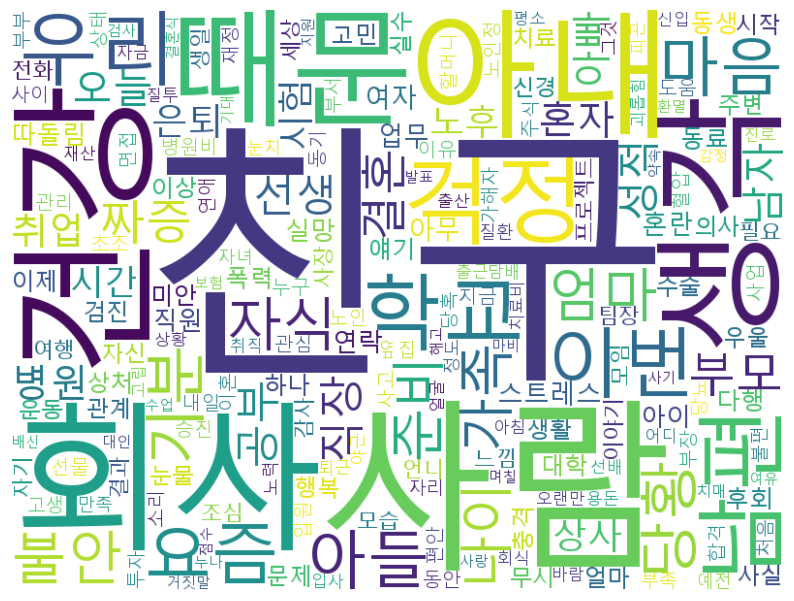

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

---

## 본활동 실천

1. 적절한 데이터셋을 찾거나 생성하고, 적절한 전처리를 진행
2. TF-IDF Vectorizer를 이용하여 백터화
3. Cosine Similarity를 계산하여 입력된 문자열의 긍/부정을 판단

In [20]:
import pandas as pd

In [21]:
import re

In [24]:
from kiwipiepy import Kiwi 
Kiwikiwi = Kiwi()

In [ ]:
emotion_all_df=pd.read_csv('C:\\SKN_24\\과제\\nlp_practice\\data\\감성대화말뭉치(최종데이터)_Validation.csv')
emotion_all_df

,Unnamed: 0,연령,성별,상황키워드,신체질환,감정_대분류,감정_소분류,사람문장1,시스템문장1,사람문장2,시스템문장2,사람문장3,시스템문장3
0,1,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,실수하시다니 정말 미안한 마음이 크겠어요.,내 능력이 부족한 거 같은데 그만 다녀야 될거같아.,능력을 올리려면 어떤 방법이 있을까요?,퇴근 후 여가에 회사 일을 더 열심히 해서 피해가 가지 않도록 해야겠어.,꼭 좋은 결과 있길 바라요.
1,2,청년,남성,"진로,취업,직장",해당없음,불안,두려운,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,큰 프로젝트를 혼자 하셔서 고민이 많겠네요.,나에게 너무 크게 느껴지는 중요한 프로젝트라 버거운 느낌이 들어.,프로젝트를 잘하시기 위해서 어떤 걸 할 수 있나요?,동료 직원에게 도움을 요청해서 같이 해결해야겠어.,동료 직원에게 도움을 요청하기로 하셨군요.
2,3,청년,남성,"진로,취업,직장",해당없음,불안,두려운,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.,무섭게 생겼는데도 업무를 보려면 친해져야 할 것 같단말이야.,상사분과 친해질 수 있는 방법은 무엇이 있을까요?,먼저 다가가서 말을 걸어볼게.,직장 상사와 친해지시면 좋겠네요.
3,4,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.,첫 직장이어서 잘 적응을 할 수 있을지 모르겠어.,잘 적응 하시려면 무엇을 할 수 있을까요?,직장 동료와 상사들이랑 친하게 지내야겠어.,직장에 잘 적응하시길 바라요.
4,5,청년,남성,"진로,취업,직장",해당없음,불안,두려운,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,직장 사람들 관계에 대해서 고민이시군요.,내가 낯가림이 심해서 친해질 수 있을지 모르겠어.,직장 사람들과 친해지려면 무슨 방법이 있을까요?,서로 같은 취미를 공유하고 얘기를 나누다 보면 친해질 수 있을 거 같아.,직장 사람들과 좋은 관계를 가지시길 응원해요.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6636,6637,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,나랑 비슷한 시기에 결혼하는 친구는 시댁에서 집을 해줘서 너무 부러워. 우리는 대출...,같은 시기에 결혼하는 친구들끼리 상황이 다르다 보니 마음이 좋지 않으시겠어요.,우리만 뒤처지는 것 같고. 그래도 열심히 살다 보면 우리도 집을 살 수 있겠지?,우리 부부만 뒤처지는 것 같아 속상하지만 열심히 살다 보면 집을 살 수 있다고 믿으...,NaN,NaN
6637,6638,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,친구 한 명이 결혼해서 아이를 가졌는데 너무 행복해 보이더라. 기분이 좋지만은 않아.,기분이 좋지 않으신 이유를 알고 계시나요?,나도 결혼했지만 아이도 생기지 않고 그 정도로 행복하지 않거든. 친구보다 못사는 것...,친구분과 비교하게 되어 기분이 좋지 않으셨군요. 어떻게 하면 기분이 풀릴 수 있을까요?,NaN,NaN
6638,6639,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,남들은 결혼 전에 일억을 모았다는데 난 뭐를 한 것인지 모르겠어. 자괴감만 드네.,돈을 모으는 것으로 자괴감이 드시는군요.,요새 집값이 너무 올라서 한숨만 나와.,집값이 올라 한숨만 나오시는군요.,NaN,NaN
6639,6640,청년,여성,"연애,결혼,출산",해당없음,당황,열등감,나보다 결혼을 먼저 한 친구가 부러워. 그 친구 남편은 직장도 내 남편보다 좋고 키...,먼저 결혼한 친구가 부럽군요.,맞아. 그 친구와 비교하게 되니 자존감이 낮아지는 기분이야.,비교로 자존감이 낮아지는군요.,NaN,NaN


In [33]:
def clean_text(s):      #s는 str 문자열
    s = str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [34]:
def kiwi_nouns(text: str):
    # 명사/고유명사/대명사만 사용
    toks = kiwi.tokenize(clean_text(text))
    words = [t.form for t in toks if t.tag.startswith("N") and len(t.form) > 1]
    return words
texts = corpus.fillna("").astype(str).map(clean_text)

In [29]:
#!pip install scikit-learn 

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------- ----------------------------- 2.4/8.9 MB 11.2 MB/s eta 0:00:01
   --------------------- ------------------ 4.7/8.9 MB 11.4 MB/s eta 0:00:01
   ------------------------------ --------- 6.8/8.9 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 10.4 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   -- ------------------------------------- 2.1/41.3 MB 9.8 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/41.3 MB 10.8 MB/s eta 0:00:04
   ------ --------------------------------- 7.1/41.3 MB 11.2 MB/s eta 0:00:04
   --------- ------------------------------ 9.4/41.3 MB 11.3 MB/s eta 0:00:03
   ----------- ---------------------------- 11.8/41.3 MB 11.4

In [35]:
# TF_IDF 백터화
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(   #TfidfVectorizer=문장을 숫자 벡터로 바꿔주는 도구 -> 각 단어의 “중요도”를 계산
    tokenizer=kiwi_nouns,       #기본 토크나이저 대신 Kiwi 명사 추출 함수 사용 -> 문장을 공백 기준으로 자르는 게 아니라, Kiwi로 형태소 분석 후 명사만 반환(TF-IDF는 명사 기준으로 계산됨)
    token_pattern=None,   # tokenizer 필수(기본 정규식 토큰 규칙)
    min_df=2              # 너무 희귀 단어 제거(최소 2번 이상 등장한 단어만 사용+한 번만 등장한 희귀 단어 제거+노이즈 줄이기)
)

X = vectorizer.fit_transform(texts) #fit: 전체 데이터에서 단어 사전 생성, 단어 빈도 계산 / transform: 각 문장을 TF-IDF 벡터로 변환
X.shape

(6641, 1613)

In [ ]:
# 감정 라벨 긍/부정으로 매핑
# 감정을 pos/neg로 변환하는 함수 생성
# 긍정 = pos / 감정이 pos_set에 있으면 -> "pos"
# 부정 = neg / 감정이 neg_set에 있으면 -> "neg"     둘 다 아니면 -> None (제외 대상)
pos_set = {"기쁨",}  
neg_set = {"불안","슬픔", "당황", "분노", "상처"}

In [ ]:
# 감정이 pos_set에 있으면 -> "pos"
# 감정이 neg_set에 있으면 -> "neg" 
def to_sentiment(emotion):
    if emotion in pos_set:
        return "pos"
    if emotion in neg_set:
        return "neg"
    return None

In [ ]:
#원본 데이터 복사
df = emotion_all_df.copy()

#감정 컬럼 변환
df["sentiment"] = df["감정_대분류"].map(to_sentiment)

#pos/neg 아닌 데이터 제거
df = df.dropna(subset=["sentiment"])

#텍스트 전처리
#결측값 -> 빈 문자열
#문자열 타입으로 변환
#clean_text() 함수 적용 (공백 정리 등)
texts = df["사람문장1"].fillna("").astype(str).map(clean_text)

X = vectorizer.fit_transform(texts)

In [40]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [41]:
pos_idx = np.where(df["sentiment"].values == "pos")[0]
neg_idx = np.where(df["sentiment"].values == "neg")[0]

In [ ]:
def predict_sentiment(user_text: str):  # user_text: 사용자 입력 문장
    v = vectorizer.transform([user_text])   #vectorizer: TF_IDF로 학습된 상태 / transform(): 문장 -> 숫자로 벡터로 바꿔주는 것임 / user_text를 리스트 형태로 넣음
    sims = cosine_similarity(v, X).ravel()  # X=전체 학습 문장들의 TF_IDF 벡터 / cosine_similarity(v, X)= 입력 문장, 전체 문장 각각의 유사도 계산

    pos_score = sims[pos_idx].mean() if len(pos_idx) else 0 #pos_idx = 긍정 문장들의 인덱스 / sims[pos_idx] = 긍정 문장들과의 유사도만 뽑음 /.mean() = 평균값 계산
    neg_score = sims[neg_idx].mean() if len(neg_idx) else 0 #neg_idx= 부정 문장들의 인덱스 
    
    pred = "pos" if pos_score >= neg_score else "neg"   #긍정 평균 유사도가 더 크면 -> "pos" / 아니면 -> "neg"
    return pred, float(pos_score), float(neg_score) # 결과 반환

In [44]:
predict_sentiment("기쁨")
predict_sentiment("불안 우울")

('neg', 0.0008334552835126769, 0.013891584658190622)

---